In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv("heart.csv")
df = pd.read_csv("heart.csv")

In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()

In [7]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
y_pred = tree.predict(X_test)


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9853658536585366


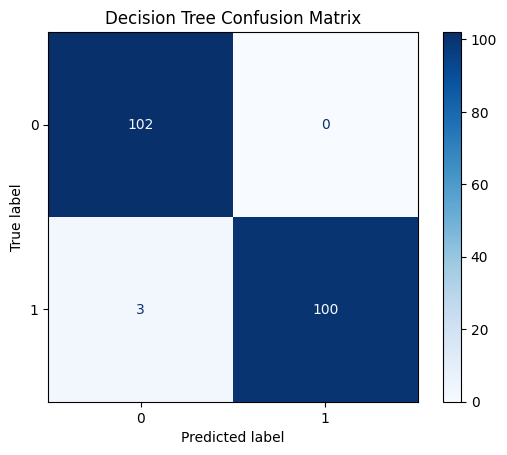

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [18]:
tree_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_depth3.fit(X_train, y_train)

y_pred_depth3 = tree_depth3.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_depth3))

Accuracy: 0.7804878048780488


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366


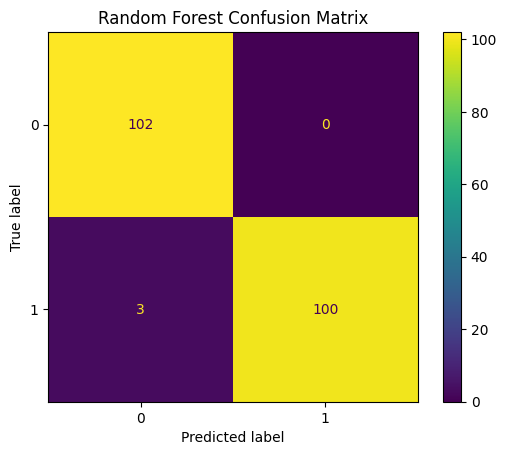

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


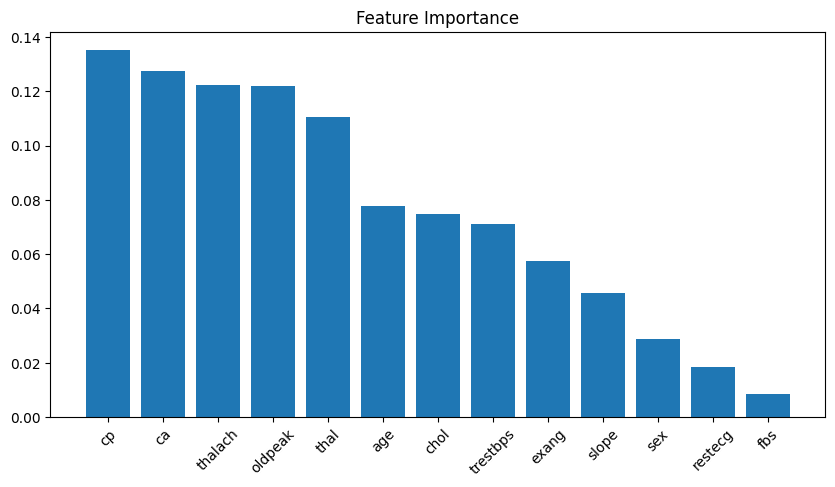

In [24]:
plt.figure(figsize=(10,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()